# Spatially-lazy reads and per-ROI extraction

**Question.** To run a pipeline on *some* of the ROIs a user drew, we want to read only the
pixels under those ROIs — not every full frame. That needs the lazy array to honour
Y/X keys *at the storage layer*, not read the whole frame and crop in RAM.

This notebook, for each backend `imread` can open:

1. checks that `arr[t, c, z, y0:y1, x0:x1]` is **correct** (matches an in-memory reference);
2. measures whether a spatial crop is **cheaper** than a full-frame read — in time and in
   bytes allocated — which is the signature of a storage-level crop;
3. benchmarks extracting traces for **one / some / all** ROIs from a `RoiLabelStore`
   (the same object the manual-ROI widget writes), against the naive full-frame path.

Everything is self-contained: a synthetic movie is written to every backend under a
scratch directory, and ROIs come from `manual_labels.zarr` next to your data if you point
`DATA_PATH` at a real dataset, otherwise from a synthetic label store.

In [1]:
import time, tracemalloc, shutil
from pathlib import Path

import numpy as np
import pandas as pd

import mbo_utilities as mbo
from mbo_utilities.annotation.store import RoiLabelStore
from mbo_utilities.annotation.ngff import LabelsZarr

# Point this at a real dataset (file or directory) to use it and the ROIs drawn on it.
# Leave as None to generate a synthetic movie.
DATA_PATH = None

SCRATCH = Path.home() / ".mbo" / "tests" / "lbm" / "mbo_utilities" / "test_outputs" / "roi_lazy_bench"
SCRATCH.mkdir(parents=True, exist_ok=True)

# synthetic movie geometry (T, C, Z, Y, X)
T, C, Z, Y, X = 200, 1, 2, 512, 512
print(f"scratch: {SCRATCH}")

scratch: C:\Users\flynn\.mbo\tests\lbm\mbo_utilities\test_outputs\roi_lazy_bench


## 1. Data

A movie with a handful of bright, blinking "cells" on a noisy background, so ROI traces are
meaningful. Written once per backend with `mbo.imwrite`.

In [2]:
rng = np.random.default_rng(0)

def make_movie():
    yy, xx = np.mgrid[:Y, :X]
    base = rng.integers(80, 120, size=(T, C, Z, Y, X), dtype=np.uint16)
    cells = []
    for z in range(Z):
        for _ in range(6):
            cy, cx, r = rng.integers(40, Y - 40), rng.integers(40, X - 40), rng.integers(6, 14)
            disc = (yy - cy) ** 2 + (xx - cx) ** 2 <= r**2
            trace = (rng.random(T) < 0.05).astype(float)
            # exponential decay after each event
            for i in range(1, T):
                trace[i] = max(trace[i], trace[i - 1] * 0.8)
            base[:, 0, z][:, disc] += (trace[:, None] * 600).astype(np.uint16)
            cells.append((z, cy, cx, r, disc))
    return base, cells

if DATA_PATH is None:
    ref, cells = make_movie()
    print("synthetic reference:", ref.shape, ref.dtype, f"{ref.nbytes/1e6:.0f} MB")
else:
    src = mbo.imread(DATA_PATH)
    ref = np.asarray(src[:T]) if src.nt > T else np.asarray(src[:])
    cells = None
    print("loaded reference from", DATA_PATH, ref.shape, ref.dtype)

synthetic reference: (200, 1, 2, 512, 512) uint16 210 MB


In [3]:
# write the reference to every backend we want to probe
BACKENDS = {".tiff": "tiff", ".zarr": "zarr", ".h5": "h5", ".bin": "bin"}
paths = {}
src_arr = mbo.imread(ref, dims="TCZYX")
for ext, name in BACKENDS.items():
    out = SCRATCH / name
    if out.exists():
        shutil.rmtree(out)
    out.mkdir(parents=True)
    t0 = time.perf_counter()
    kw = {"ome": True} if ext == ".zarr" else {}
    mbo.imwrite(src_arr, out, ext=ext, overwrite=True, **kw)
    paths[name] = out
    print(f"{name:5s} written in {time.perf_counter()-t0:5.1f}s -> {out}")

dims TCZYX -> TCZYX  shape (200, 1, 2, 512, 512)


Writing TIFF:   0%|          | 0/400 [00:00<?, ?pg/s]

tiff  written in   0.1s -> C:\Users\flynn\.mbo\tests\lbm\mbo_utilities\test_outputs\roi_lazy_bench\tiff


Writing Zarr:   0%|          | 0/200 [00:00<?, ?frames/s]

zarr  written in   0.8s -> C:\Users\flynn\.mbo\tests\lbm\mbo_utilities\test_outputs\roi_lazy_bench\zarr


...

Saving data_raw.bin:   0%|          | 0/1 [00:00<?, ?it/s]

No frame rate found; defaulting fs=10


Saving data_raw.bin:   0%|          | 0/1 [00:00<?, ?it/s]

No frame rate found; defaulting fs=10


bin   written in   0.5s -> C:\Users\flynn\.mbo\tests\lbm\mbo_utilities\test_outputs\roi_lazy_bench\bin


In [4]:
# open each backend lazily (plus the in-memory numpy wrapper as a control)
def open_backend(name, out):
    if name == "tiff":
        return mbo.imread(sorted(out.rglob("*.tif*")))
    if name == "zarr":
        return mbo.imread(next(out.rglob("*.zarr")))
    if name == "h5":
        return mbo.imread(next(out.rglob("*.h5")))
    if name == "bin":
        return mbo.imread(out)
    raise ValueError(name)

arrays = {"numpy": mbo.imread(ref, dims="TCZYX")}
for name, out in paths.items():
    try:
        arrays[name] = open_backend(name, out)
    except Exception as e:  # noqa: BLE001 - report, keep going
        print(f"!! {name}: {type(e).__name__}: {e}")

for name, arr in arrays.items():
    print(f"{name:6s} {type(arr).__name__:22s} shape={arr.shape} ndim={arr.ndim} dtype={arr.dtype}")

dims TCZYX -> TCZYX  shape (200, 1, 2, 512, 512)


numpy  NumpyArray             shape=(200, 1, 2, 512, 512) ndim=5 dtype=uint16
tiff   TiffArray              shape=(200, 1, 2, 512, 512) ndim=5 dtype=uint16
zarr   ZarrArray              shape=(200, 1, 2, 512, 512) ndim=5 dtype=uint16
h5     H5Array                shape=(200, 1, 2, 512, 512) ndim=5 dtype=uint16
bin    Suite2pArray           shape=(200, 1, 2, 512, 512) ndim=5 dtype=int16


### Indexing helper

Backends agree on `(T, C, Z, Y, X)` except `BinArray`, which stays 3-D `(T, Y, X)` per plane
(suite2p's input contract). `read()` builds the right key for whichever rank it gets.

In [5]:
def read(arr, t=slice(None), z=0, y=slice(None), x=slice(None)):
    """Read a block from a lazy array of rank 5, 4 or 3 and return (T, Y, X)."""
    if arr.ndim == 5:
        out = arr[t, 0, z, y, x]
    elif arr.ndim == 4:
        out = arr[t, z, y, x]
    else:  # 3-D (T, Y, X): plane already selected
        out = arr[t, y, x]
    out = np.asarray(out)
    return out.reshape((-1,) + out.shape[-2:])

def ref_read(t=slice(None), z=0, y=slice(None), x=slice(None)):
    return ref[t, 0, z, y, x]

## 2. Correctness: spatial keys return the right pixels

In [6]:
cases = {
    "corner crop":  dict(t=slice(0, 20), z=0, y=slice(0, 32), x=slice(0, 32)),
    "middle crop":  dict(t=slice(50, 70), z=1, y=slice(200, 264), x=slice(300, 340)),
    "strided rows": dict(t=slice(0, 10), z=0, y=slice(0, 100, 3), x=slice(10, 60)),
    "single frame": dict(t=5, z=1, y=slice(100, 132), x=slice(100, 132)),
    "int pixel":    dict(t=slice(0, 50), z=0, y=256, x=256),
}
rows = []
for name, arr in arrays.items():
    for case, kw in cases.items():
        try:
            got = read(arr, **kw)
            exp = ref_read(**kw).reshape(got.shape)
            ok = np.array_equal(got, exp)
            rows.append((name, case, "ok" if ok else "MISMATCH", got.shape))
        except Exception as e:  # noqa: BLE001
            rows.append((name, case, f"{type(e).__name__}: {e}", None))
pd.DataFrame(rows, columns=["backend", "case", "result", "shape"]).pivot(index="backend", columns="case", values="result")

case,corner crop,int pixel,middle crop,single frame,strided rows
backend,,,,,
bin,ok,AxisError: axis 2 is out of bounds for array o...,ok,ok,ok
h5,ok,ok,ok,ok,ok
numpy,ok,ok,ok,ok,ok
tiff,ok,ok,ok,ok,ok
zarr,ok,ok,ok,ok,ok


## 3. Is the crop lazy? Time and bytes: full frame vs 32×32 crop

If the backend pushes Y/X into the read, a 32×32 crop of a 512×512 frame touches 1/256 of the
pixels and should be *much* faster and allocate *much* less. If it reads the full frame and
crops in RAM, the two columns will be nearly identical.

`alloc_ratio` = peak bytes (full) / peak bytes (crop). `time_ratio` likewise.
Values near **1** mean "not spatially lazy"; values approaching **256** mean storage-level crop.

Two caveats: memmap-backed readers (`.bin`, in-memory numpy) allocate nothing either way, so
only the time column is meaningful for them; and zarr's `alloc_ratio` is bounded by its chunk
layout — the default `imwrite` layout is one chunk per full Y×X plane (tuned for the GUI's
scrub pattern), so a 32×32 window still decodes the whole plane chunk.

In [7]:
NT = 50
Y0, X0, W = 200, 200, 32

def measure(fn, repeats=3):
    best_t, peak = np.inf, 0
    for _ in range(repeats):
        tracemalloc.start()
        t0 = time.perf_counter()
        fn()
        dt = time.perf_counter() - t0
        _, pk = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        best_t, peak = min(best_t, dt), max(peak, pk)
    return best_t, peak

rows = []
for name, arr in arrays.items():
    t_full, b_full = measure(lambda: read(arr, t=slice(0, NT), z=0))
    t_crop, b_crop = measure(lambda: read(arr, t=slice(0, NT), z=0, y=slice(Y0, Y0 + W), x=slice(X0, X0 + W)))
    rows.append(dict(backend=name,
                     full_ms=t_full * 1e3, crop_ms=t_crop * 1e3, time_ratio=t_full / max(t_crop, 1e-9),
                     full_MB=b_full / 1e6, crop_MB=b_crop / 1e6, alloc_ratio=b_full / max(b_crop, 1)))
lazy_df = pd.DataFrame(rows).set_index("backend")
# memmap-backed readers (numpy control, suite2p .bin) never allocate through the
# Python allocator, so tracemalloc sees ~0 MB either way: treat "nothing materialized"
# as lazy too, since the crop is then a view onto the OS page cache.
lazy_df["spatially_lazy"] = (lazy_df["alloc_ratio"] > 8) | (lazy_df["full_MB"] < 1)
lazy_df.round(2)

,full_ms,crop_ms,time_ratio,full_MB,crop_MB,alloc_ratio,spatially_lazy
backend,,,,,,,
numpy,0.01,0.01,1.10,0.00,0.00,0.86,True
tiff,35.10,33.54,1.05,26.75,26.75,1.00,False
zarr,37.47,24.94,1.50,78.83,26.60,2.96,False
h5,49.65,56.11,0.88,26.21,0.10,254.75,True
bin,0.05,0.04,1.19,0.00,0.00,0.94,True


### `%%timeit` — one cell per backend, full-frame block vs crop

In [8]:
%%timeit -n 3 -r 3
# numpy: full frames
_ = read(arrays["numpy"], t=slice(0, NT), z=0)

6 μs ± 3.88 μs per loop (mean ± std. dev. of 3 runs, 3 loops each)


In [9]:
%%timeit -n 3 -r 3
# numpy: 32x32 crop
_ = read(arrays["numpy"], t=slice(0, NT), z=0, y=slice(Y0, Y0 + W), x=slice(X0, X0 + W))

The slowest run took 4.12 times longer than the fastest. This could mean that an intermediate result is being cached.
6.17 μs ± 4.2 μs per loop (mean ± std. dev. of 3 runs, 3 loops each)


In [10]:
%%timeit -n 3 -r 3
# tiff: full frames
_ = read(arrays["tiff"], t=slice(0, NT), z=0)

16.3 ms ± 442 μs per loop (mean ± std. dev. of 3 runs, 3 loops each)


In [11]:
%%timeit -n 3 -r 3
# tiff: 32x32 crop
_ = read(arrays["tiff"], t=slice(0, NT), z=0, y=slice(Y0, Y0 + W), x=slice(X0, X0 + W))

16 ms ± 303 μs per loop (mean ± std. dev. of 3 runs, 3 loops each)


In [12]:
%%timeit -n 3 -r 3
# zarr: full frames
_ = read(arrays["zarr"], t=slice(0, NT), z=0)

30 ms ± 421 μs per loop (mean ± std. dev. of 3 runs, 3 loops each)


In [13]:
%%timeit -n 3 -r 3
# zarr: 32x32 crop
_ = read(arrays["zarr"], t=slice(0, NT), z=0, y=slice(Y0, Y0 + W), x=slice(X0, X0 + W))

14.8 ms ± 222 μs per loop (mean ± std. dev. of 3 runs, 3 loops each)


In [14]:
%%timeit -n 3 -r 3
# h5: full frames
_ = read(arrays["h5"], t=slice(0, NT), z=0)

65.1 ms ± 4.71 ms per loop (mean ± std. dev. of 3 runs, 3 loops each)


In [15]:
%%timeit -n 3 -r 3
# h5: 32x32 crop
_ = read(arrays["h5"], t=slice(0, NT), z=0, y=slice(Y0, Y0 + W), x=slice(X0, X0 + W))

58.4 ms ± 2.17 ms per loop (mean ± std. dev. of 3 runs, 3 loops each)


In [16]:
%%timeit -n 3 -r 3
# bin: full frames
_ = read(arrays["bin"], t=slice(0, NT), z=0)

The slowest run took 4.00 times longer than the fastest. This could mean that an intermediate result is being cached.
15.1 μs ± 10.5 μs per loop (mean ± std. dev. of 3 runs, 3 loops each)


In [17]:
%%timeit -n 3 -r 3
# bin: 32x32 crop
_ = read(arrays["bin"], t=slice(0, NT), z=0, y=slice(Y0, Y0 + W), x=slice(X0, X0 + W))

13.6 μs ± 6.87 μs per loop (mean ± std. dev. of 3 runs, 3 loops each)


## 4. ROIs: extract traces for one / some / all

`RoiLabelStore` is what the manual-ROI widget edits and what `manual_labels.zarr` reloads. Each
ROI is a set of labelled pixels on one z-plane. To run *some* ROIs we:

1. take the ROI's bounding box,
2. read only that box from the lazy array (`arr[t, 0, z, y0:y1, x0:x1]`),
3. apply the ROI mask inside the box and average.

Cost scales with the ROI area, not the frame — *if* step 2 is lazy in Y/X.

In [18]:
def load_or_make_store():
    if DATA_PATH is not None:
        from mbo_utilities.gui.manual_roi import labels_path
        lp = labels_path(DATA_PATH)
        if lp.exists():
            store = LabelsZarr.load(lp)
            print(f"loaded {len(store.rois)} ROIs from {lp}")
            return store
        print(f"no labels at {lp}; drawing synthetic ROIs instead")
    store = RoiLabelStore(nz=ref.shape[2], ny=ref.shape[3], nx=ref.shape[4])
    if cells is not None:
        for z, cy, cx, r, disc in cells:
            store.add_roi(z, disc)
    else:
        yy, xx = np.mgrid[: store.ny, : store.nx]
        for z in range(store.nz):
            for _ in range(6):
                cy, cx = rng.integers(40, store.ny - 40), rng.integers(40, store.nx - 40)
                store.add_roi(z, (yy - cy) ** 2 + (xx - cx) ** 2 <= 100)
    print(f"synthetic store with {len(store.rois)} ROIs")
    return store

store = load_or_make_store()
pd.DataFrame([dict(roi=i, z=r.z, area=r.area) for i, r in enumerate(store.rois)]).T

synthetic store with 12 ROIs


,0,1,2,3,4,5,6,7,8,9,10,11
roi,0,1,2,3,4,5,6,7,8,9,10,11
z,0,0,0,0,0,0,1,1,1,1,1,1
area,113,317,253,253,317,529,149,105,253,149,253,197


In [19]:
def roi_bbox(store, i):
    """(z, y0, y1, x0, x1, mask_in_box) for ROI i (label value i+1)."""
    rec = store.rois[i]
    plane = store.labels[rec.z] == (i + 1)
    rows, cols = np.nonzero(plane)
    y0, y1, x0, x1 = rows.min(), rows.max() + 1, cols.min(), cols.max() + 1
    return rec.z, y0, y1, x0, x1, plane[y0:y1, x0:x1]

def roi_trace(arr, store, i, t=slice(None)):
    """Mean pixel value inside ROI i over t — reads only the ROI's bounding box."""
    z, y0, y1, x0, x1, m = roi_bbox(store, i)
    box = read(arr, t=t, z=z, y=slice(y0, y1), x=slice(x0, x1))
    return box[:, m].mean(axis=1)

def roi_traces(arr, store, indices, t=slice(None)):
    return np.stack([roi_trace(arr, store, i, t) for i in indices])

def roi_traces_naive(arr, store, indices, t=slice(None)):
    """Read whole frames for every plane touched, then mask — the non-lazy baseline."""
    out = []
    planes = {}
    for i in indices:
        z = store.rois[i].z
        if z not in planes:
            planes[z] = read(arr, t=t, z=z)
        out.append(planes[z][:, store.labels[z] == (i + 1)].mean(axis=1))
    return np.stack(out)

# sanity: bbox path == naive path, on the reference
ALL = list(range(len(store.rois)))
SOME = ALL[:3]
ONE = ALL[:1]
a = roi_traces(arrays["numpy"], store, ALL, t=slice(0, NT))
b = roi_traces_naive(arrays["numpy"], store, ALL, t=slice(0, NT))
print("bbox path == naive path:", np.allclose(a, b), a.shape)

bbox path == naive path: True (12, 50)


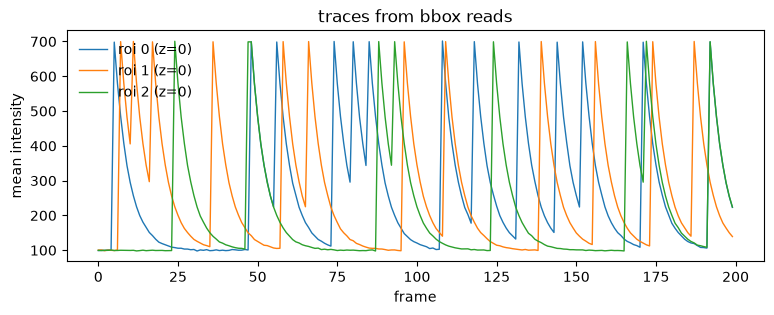

In [20]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 3))
for i, tr in zip(SOME, roi_traces(arrays["numpy"], store, SOME)):
    ax.plot(tr, lw=1, label=f"roi {i} (z={store.rois[i].z})")
ax.set(xlabel="frame", ylabel="mean intensity", title="traces from bbox reads")
ax.legend(frameon=False)
plt.show()

### Per-backend: one / some / all ROIs vs the naive full-frame path

`speedup_all` = naive / bbox for *all* ROIs. Bigger than 1 means the ROI path wins; for a
backend that isn't spatially lazy, the bbox path re-reads a full frame per ROI and will be
**slower** than naive (which reads each plane once).

In [21]:
rows = []
for name, arr in arrays.items():
    t_one, _  = measure(lambda: roi_traces(arr, store, ONE, t=slice(0, NT)), repeats=2)
    t_some, _ = measure(lambda: roi_traces(arr, store, SOME, t=slice(0, NT)), repeats=2)
    t_all, _  = measure(lambda: roi_traces(arr, store, ALL, t=slice(0, NT)), repeats=2)
    t_naive, _ = measure(lambda: roi_traces_naive(arr, store, ALL, t=slice(0, NT)), repeats=2)
    rows.append(dict(backend=name, one_ms=t_one*1e3, some_ms=t_some*1e3, all_ms=t_all*1e3,
                     naive_all_ms=t_naive*1e3, speedup_all=t_naive / max(t_all, 1e-9)))
roi_df = pd.DataFrame(rows).set_index("backend")
roi_df.round(1)

,one_ms,some_ms,all_ms,naive_all_ms,speedup_all
backend,,,,,
numpy,0.7,2.1,9.0,4.3,0.5
tiff,41.9,116.0,451.5,73.2,0.2
zarr,24.6,78.3,326.2,85.7,0.3
h5,57.1,163.3,635.1,105.5,0.2
bin,0.7,1.8,9.4,3.6,0.4


### `%%timeit` — ROI extraction

In [22]:
%%timeit -n 2 -r 2
# tiff: ONE roi via bbox
_ = roi_traces(arrays["tiff"], store, ONE, t=slice(0, NT))

15.6 ms ± 962 μs per loop (mean ± std. dev. of 2 runs, 2 loops each)


In [23]:
%%timeit -n 2 -r 2
# tiff: SOME (3) rois via bbox
_ = roi_traces(arrays["tiff"], store, SOME, t=slice(0, NT))

44.8 ms ± 1.05 ms per loop (mean ± std. dev. of 2 runs, 2 loops each)


In [24]:
%%timeit -n 2 -r 2
# tiff: ALL rois via bbox
_ = roi_traces(arrays["tiff"], store, ALL, t=slice(0, NT))

174 ms ± 1.79 ms per loop (mean ± std. dev. of 2 runs, 2 loops each)


In [25]:
%%timeit -n 2 -r 2
# tiff: ALL rois, naive full-frame
_ = roi_traces_naive(arrays["tiff"], store, ALL, t=slice(0, NT))

31.8 ms ± 327 μs per loop (mean ± std. dev. of 2 runs, 2 loops each)


In [26]:
%%timeit -n 2 -r 2
# zarr: ONE roi via bbox
_ = roi_traces(arrays["zarr"], store, ONE, t=slice(0, NT))

11.7 ms ± 327 μs per loop (mean ± std. dev. of 2 runs, 2 loops each)

In [27]:
%%timeit -n 2 -r 2
# zarr: SOME (3) rois via bbox
_ = roi_traces(arrays["zarr"], store, SOME, t=slice(0, NT))

38.5 ms ± 1.13 ms per loop (mean ± std. dev. of 2 runs, 2 loops each)

In [28]:
%%timeit -n 2 -r 2
# zarr: ALL rois via bbox
_ = roi_traces(arrays["zarr"], store, ALL, t=slice(0, NT))

160 ms ± 7.16 ms per loop (mean ± std. dev. of 2 runs, 2 loops each)


In [29]:
%%timeit -n 2 -r 2
# zarr: ALL rois, naive full-frame
_ = roi_traces_naive(arrays["zarr"], store, ALL, t=slice(0, NT))

60.8 ms ± 1.65 ms per loop (mean ± std. dev. of 2 runs, 2 loops each)


In [30]:
%%timeit -n 2 -r 2
# h5: ONE roi via bbox
_ = roi_traces(arrays["h5"], store, ONE, t=slice(0, NT))

54.2 ms ± 1.02 ms per loop (mean ± std. dev. of 2 runs, 2 loops each)


In [31]:
%%timeit -n 2 -r 2
# h5: SOME (3) rois via bbox
_ = roi_traces(arrays["h5"], store, SOME, t=slice(0, NT))

166 ms ± 3.73 ms per loop (mean ± std. dev. of 2 runs, 2 loops each)


In [32]:
%%timeit -n 2 -r 2
# h5: ALL rois via bbox
_ = roi_traces(arrays["h5"], store, ALL, t=slice(0, NT))

649 ms ± 2.76 ms per loop (mean ± std. dev. of 2 runs, 2 loops each)


In [33]:
%%timeit -n 2 -r 2
# h5: ALL rois, naive full-frame
_ = roi_traces_naive(arrays["h5"], store, ALL, t=slice(0, NT))

117 ms ± 5.43 ms per loop (mean ± std. dev. of 2 runs, 2 loops each)


In [34]:
%%timeit -n 2 -r 2
# bin: ONE roi via bbox
_ = roi_traces(arrays["bin"], store, ONE, t=slice(0, NT))

614 μs ± 7.07 μs per loop (mean ± std. dev. of 2 runs, 2 loops each)


In [35]:
%%timeit -n 2 -r 2
# bin: SOME (3) rois via bbox
_ = roi_traces(arrays["bin"], store, SOME, t=slice(0, NT))

1.68 ms ± 41.7 μs per loop (mean ± std. dev. of 2 runs, 2 loops each)


In [36]:
%%timeit -n 2 -r 2
# bin: ALL rois via bbox
_ = roi_traces(arrays["bin"], store, ALL, t=slice(0, NT))

6.86 ms ± 153 μs per loop (mean ± std. dev. of 2 runs, 2 loops each)


In [37]:
%%timeit -n 2 -r 2
# bin: ALL rois, naive full-frame
_ = roi_traces_naive(arrays["bin"], store, ALL, t=slice(0, NT))

3.11 ms ± 47.5 μs per loop (mean ± std. dev. of 2 runs, 2 loops each)


## 5. Summary

In [38]:
summary = lazy_df[["time_ratio", "alloc_ratio", "spatially_lazy"]].join(roi_df[["all_ms", "naive_all_ms", "speedup_all"]])
summary.round(2)

,time_ratio,alloc_ratio,spatially_lazy,all_ms,naive_all_ms,speedup_all
backend,,,,,,
numpy,1.10,0.86,True,8.99,4.33,0.48
tiff,1.05,1.00,False,451.53,73.19,0.16
zarr,1.50,2.96,False,326.25,85.66,0.26
h5,0.88,254.75,True,635.10,105.46,0.17
bin,1.19,0.94,True,9.36,3.57,0.38


**Reading the table**

- `spatially_lazy` (`alloc_ratio` ≫ 1): the backend reads only the requested Y/X window from
  storage. Running a subset of ROIs on it costs ~area of those ROIs.
- Not lazy (`alloc_ratio` ≈ 1): every ROI read pulls full frames. For these, "run some ROIs"
  must read each touched plane **once** and mask in RAM (the `naive` path) — or the backend's
  `__getitem__` needs to push `y_key`/`x_key` down to the file reader (tifffile page
  sub-regions / h5py hyperslabs / memmap) before this becomes worthwhile.
- Zarr sits in between: it reads only *touched chunks*, so spatial laziness is a
  **chunk-layout** decision. Writing with spatial chunks (e.g. `(1, 1, 1, 64, 64)`) instead of
  whole-plane chunks would make ROI reads scale with ROI area at the cost of scrub speed.
- The `bin` / `int pixel` failure in §2 is a backend bug: `Suite2pArray` does not accept
  integer Y and X keys together.